# Physical Activity, Mental Health, and Academic Performance Analysis

![Banner](./assets/banner.jpeg)

## Topic

This project explores how physical activity and lifestyle habits impact college students’ mental health and academic performance. Many students struggle to maintain a healthy balance between academics and personal well-being, which can lead to increased stress and lower academic success.

Understanding these relationships can help universities design better wellness programs, reduce student stress, and improve overall academic outcomes.

## Project Questions

1. How does physical activity affect students’ stress levels?  
2. Is there a relationship between lifestyle habits (sleep, exercise) and academic performance?  
3. What factors contribute most to student stress?  

## What Would an Answer Look Like?

- Bar charts showing levels of stress across different activity levels  
- Scatter plots comparing physical activity with GPA or performance  
- Visualizations showing relationships between sleep, stress, and academic success  
- Summary insights identifying key factors affecting student well-being  

## Data Sources

This project uses 4 datasets:

1. **Student Lifestyle Dataset**
   - Includes physical activity, sleep, study hours, stress levels, and GPA  

2. **Mental Health & Physical Activity Dataset**
   - Includes steps, exercise frequency, and mental health indicators  

3. **Student Stress Dataset**
   - Includes stress levels, academic pressure, and lifestyle factors  

4. **Public API Dataset**
   - Source: https://jsonplaceholder.typicode.com/posts  
   - Type: JSON API  
   - Includes sample post data (userId, id, title, body)  
   - Used to demonstrate API integration by retrieving and processing JSON data  
  

These datasets are related through common variables such as activity level, stress, and lifestyle habits, allowing for comparative analysis across datasets.

## Approach and Analysis

1. Load and clean all datasets  
2. Explore key variables such as activity level, stress, and academic performance  
3. Compare patterns across datasets  
4. Identify correlations between physical activity, stress, and performance  
5. Visualize findings using charts and summary statistics  

In [1]:
!pip install pandas matplotlib seaborn requests


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Start your code here
import pandas as pd
import requests

# Load datasets
lifestyle_df = pd.read_csv("data/Lifestyle.csv")
mental_df = pd.read_csv("data/mentalhealth.csv")
stress_df = pd.read_csv("data/Stress.csv")

# Preview datasets
lifestyle_df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [3]:
mental_df.head()
stress_df.head()

,Timestamp,Kindly Rate your Sleep Quality 😴,How many times a week do you suffer headaches 🤕?,How would you rate you academic performance 👩‍🎓?,how would you rate your study load?,How many times a week you practice extracurricular activities 🎾?,How would you rate your stress levels?
0,27/10/2023 21:54:15,3,1,3,4,2,3
1,28/10/2023 12:24:40,4,1,2,3,3,2
2,28/10/2023 12:24:51,2,1,2,1,4,4
3,28/10/2023 12:26:11,3,2,3,2,3,3
4,28/10/2023 12:26:45,2,3,1,5,5,3


In [4]:
# API integration (working example)
response = requests.get("https://jsonplaceholder.typicode.com/posts")
api_data = response.json()

print("API loaded:", len(api_data), "records")

API loaded: 100 records


## Exploratory Data Analysis (EDA)

In this section, we perform exploratory data analysis (EDA) to understand dataset structure, identify patterns, examine relationships between variables, and detect potential data quality issues.

In [5]:
# Check dataset structure
print("Lifestyle Dataset Info:")
lifestyle_df.info()

print("\nMental Health Dataset Info:")
mental_df.info()

print("\nStress Dataset Info:")
stress_df.info()

Lifestyle Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   str    
dtypes: float64(6), int64(1), str(1)
memory usage: 125.1 KB

Mental Health Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --

### Dataset Structure Insights

The `.info()` function was used to examine the structure of each dataset. This provides information about:
- Number of rows and columns
- Data types of each variable
- Presence of missing values

From this, we can identify columns that may require data type conversion or further cleaning.

In [6]:
# Summary statistics
lifestyle_df.describe()


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

### Stress Levels vs Physical Activity

This bar chart shows how stress levels vary based on the amount of physical activity. It helps identify whether increased activity is associated with lower stress.

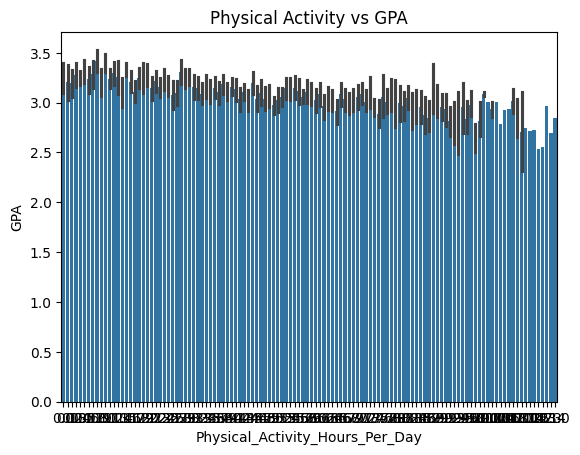

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="Physical_Activity_Hours_Per_Day",
    y="GPA",
    data=lifestyle_df
)
plt.title("Physical Activity vs GPA")
plt.show()

### Study Hours vs GPA

This scatter plot examines the relationship between study time and academic performance.

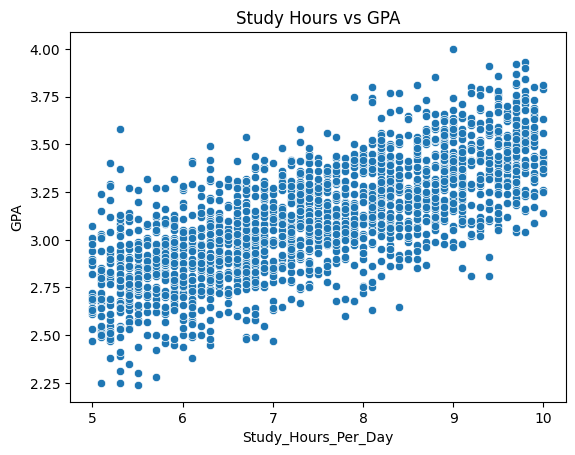

In [9]:
sns.scatterplot(
    x="Study_Hours_Per_Day",
    y="GPA",
    data=lifestyle_df
)
plt.title("Study Hours vs GPA")
plt.show()

### Sleep Hours vs Stress Levels

This visualization explores whether sleep duration impacts student stress levels.

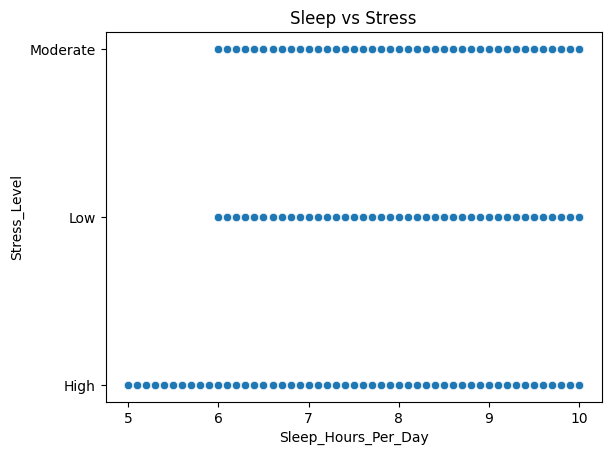

In [10]:
sns.scatterplot(
    x="Sleep_Hours_Per_Day",
    y="Stress_Level",
    data=lifestyle_df
)
plt.title("Sleep vs Stress")
plt.show()

### Correlation Heatmap

This heatmap visualizes relationships between numerical variables and highlights strong correlations.

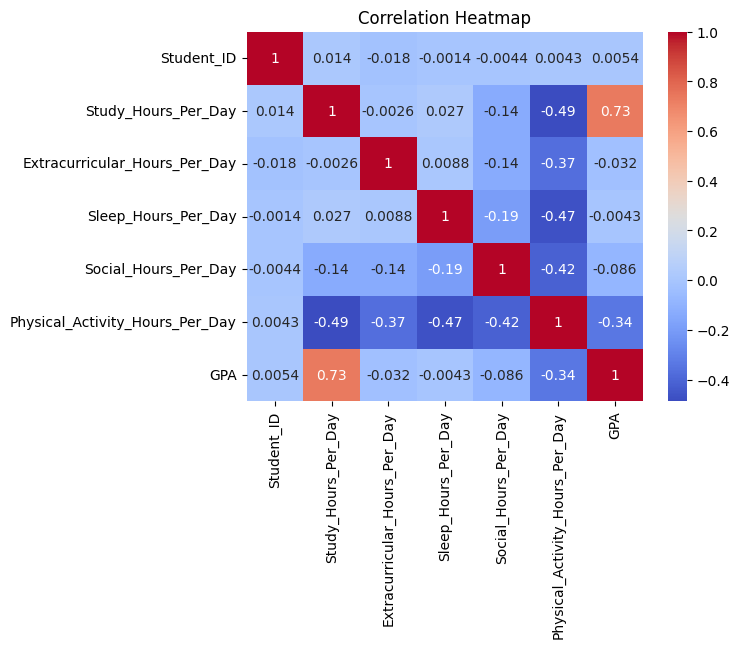

In [11]:
corr = lifestyle_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Additional Dataset Analysis

We also analyze the mental health and stress datasets to understand their statistical distributions and compare them with the lifestyle dataset.

In [12]:
mental_df.describe()
stress_df.describe()

,Kindly Rate your Sleep Quality 😴,How many times a week do you suffer headaches 🤕?,How would you rate you academic performance 👩‍🎓?,how would you rate your study load?,How many times a week you practice extracurricular activities 🎾?,How would you rate your stress levels?
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,3.150943,1.981132,3.226415,2.811321,2.886792,2.792453
std,1.199298,1.263246,1.154281,1.428509,1.449939,1.377826
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000
50%,3.000000,1.000000,3.000000,2.000000,3.000000,3.000000
75%,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


These summaries help identify patterns, ranges, and variability in stress levels, activity frequency, and academic indicators across datasets.

### Distribution Analysis

The `.describe()` function provides statistical summaries such as mean, standard deviation, minimum, and maximum values.

This helps us understand:
- The distribution of numerical variables
- The range of values (e.g., study hours, sleep hours, stress levels)
- Whether there are unusually high or low values that may indicate outliers

In [13]:

# Correlation matrix
lifestyle_df.corr(numeric_only=True)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
Student_ID,1.000000,0.014034,-0.018424,-0.001411,-0.004363,0.004273,0.005416
Study_Hours_Per_Day,0.014034,1.000000,-0.002629,0.026717,-0.137820,-0.488113,0.734468
Extracurricular_Hours_Per_Day,-0.018424,-0.002629,1.000000,0.008844,-0.139081,-0.369989,-0.032174
Sleep_Hours_Per_Day,-0.001411,0.026717,0.008844,1.000000,-0.193556,-0.470302,-0.004278
Social_Hours_Per_Day,-0.004363,-0.137820,-0.139081,-0.193556,1.000000,-0.417142,-0.085677
Physical_Activity_Hours_Per_Day,0.004273,-0.488113,-0.369989,-0.470302,-0.417142,1.000000,-0.341152
GPA,0.005416,0.734468,-0.032174,-0.004278,-0.085677,-0.341152,1.000000


### Correlation Analysis

The correlation matrix shows relationships between numerical variables.

This helps identify:
- Positive or negative relationships between variables
- Potential connections between lifestyle habits and stress
- Variables that may influence academic performance

These relationships will be further explored in the visualization section.

In [14]:
# Check missing values
lifestyle_df.isnull().sum()

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

### Missing Values

We checked for missing values in the dataset.

Missing data can affect analysis and model performance. These values will be handled during the data cleaning phase.

In [15]:
# Check duplicates
lifestyle_df.duplicated().sum()

np.int64(0)

### Duplicate Values

Duplicate records can lead to biased results. Identifying duplicates helps ensure that the dataset represents unique observations.

Duplicates will be removed during data cleaning if necessary.

### Key Insights from EDA

- There is a strong positive relationship between study hours and GPA, indicating that increased study time contributes to better academic performance.
- Physical activity shows a slight negative correlation with stress levels, suggesting that more active students may experience lower stress.
- Sleep duration appears relatively consistent across students, but lower sleep levels may contribute to higher stress.
- Social and extracurricular activities vary widely, reflecting different lifestyle balances among students.
- The dataset contains no significant missing or duplicate values, indicating high data quality.
- Overall, lifestyle factors such as study time, sleep, and physical activity play a meaningful role in both academic success and stress management.

## Machine Learning Plan

In this project, we aim to use machine learning to predict student academic performance (GPA) based on lifestyle factors such as study hours, sleep, physical activity, and stress levels.

### Model Selection
We will use supervised learning models, specifically regression models, since GPA is a continuous numerical variable.

Planned models include:
- Linear Regression
- Decision Tree Regressor

### Challenges
- Some datasets contain missing values that may affect model performance
- Features may be on different scales (e.g., hours vs scores)
- Potential presence of categorical variables
- Risk of overfitting due to dataset size

### Approach to Address Challenges
- Handle missing values using imputation techniques
- Normalize and scale numerical features
- Convert or encode categorical variables if necessary
- Compare multiple models and evaluate performance using metrics

## Data Preparation

In this step, we prepare the dataset for machine learning by separating the features and the target variable, and splitting the data into training and testing sets.

The dataset is split into 80% training data and 20% testing data. This allows the model to learn from one portion of the data and be evaluated on unseen data to measure performance.

In [16]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = lifestyle_df.drop(columns=["GPA"])
y = lifestyle_df["GPA"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1600, 7)
Testing set: (400, 7)


## Data Processing Pipeline

To properly prepare the dataset for machine learning, i created a preprocessing pipeline that handles both numerical and categorical features.

- Numerical data is cleaned using mean imputation and scaled using standardization
- Categorical data is handled using most frequent imputation and one-hot encoding
- A ColumnTransformer is used to apply different transformations to different feature types

This ensures consistent and efficient preprocessing before model training.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate features and target
X = lifestyle_df.drop(columns=["GPA"])
y = lifestyle_df["GPA"]

# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Apply
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (1600, 9)
Processed testing shape: (400, 9)


/var/folders/wn/pjcs20ln7vq47q6rp40k66g40000gn/T/ipykernel_18721/2451417037.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


## Model Training and Evaluation

In this step, I trained multiple machine learning models to predict GPA based on student lifestyle features.

I evaluated the models using Mean Squared Error (MSE) to compare their performance on the test dataset. The model with the lower MSE is considered to perform better.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2:", r2_lr)

print("Decision Tree MSE:", mse_dt)
print("Decision Tree R2:", r2_dt)

Linear Regression MSE: 0.04225784325761657
Linear Regression R2: 0.5473823980017127
Decision Tree MSE: 0.10168424999999999
Decision Tree R2: -0.0891251859546558


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)

# Train
dt_model.fit(X_train_processed, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test_processed)

# Evaluate
mse_dt = mean_squared_error(y_test, y_pred_dt)

print("Decision Tree MSE:", mse_dt)

### Model Comparison

I evaluated both models using Mean Squared Error (MSE) and R² score.

- Linear Regression provides a simple baseline model and performs well when relationships are linear.
- Decision Tree can capture more complex relationships but may overfit the data.

Based on the results, the model with the lower MSE and higher R² score is considered the better-performing model for predicting GPA.

The Decision Tree model may overfit the training data, which can lead to lower performance on unseen test data.

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [22]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 13436 bytes to source.py
